# Phase 2, Week 3: Backpropagation = Chain Rule in AI

**From Calculus to Neural Networks | Full Example | Code + Math + Intuition**

---

## The Big Idea: A Neural Network is a Giant Composite Function

Imagine you want to predict **house price** $ \hat{y} $ from **size** $ x $.

You build a **tiny neural network**:

1. **Input**: $ x $
2. **Hidden layer**:
   - $ z_1 = w_1 x + b_1 $
   - $ a_1 = \sigma(z_1) $ (sigmoid)
3. **Output layer**:
   - $ \hat{y} = w_2 a_1 + b_2 $
4. **Loss**:
   - $ L = (\hat{y} - y)^2 $

Now write $ L $ in terms of $ x $:

$$ L = \left( w_2 \cdot \sigma(w_1 x + b_1) + b_2 - y \right)^2 $$

This is a **massive composite function** — **Chain Rule is the only way** to differentiate it.

---

## Goal: Update $ w_1 $ Using Gradient Descent

To improve $ w_1 $, we need:

$$ \frac{\partial L}{\partial w_1} $$

This is a **partial derivative** because $ L $ depends on many variables.

### The Path of Influence

$$ \to \hat{y} \to a_1 \to z_1 \to w_1 $$

Chain Rule:

$$ \frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1} $$

**This is backpropagation.**

---

## Compute Each Link — Step by Step

### Link 1: $ \frac{\partial L}{\partial \hat{y}} $

$ L = (\hat{y} - y)^2 $

Power Rule:

$$ \frac{\partial L}{\partial \hat{y}} = 2(\hat{y} - y) $$

---

### Link 2: $ \frac{\partial \hat{y}}{\partial a_1} $

$ \hat{y} = w_2 a_1 + b_2 $

Derivative w.r.t. $ a_1 $:

$$ \frac{\partial \hat{y}}{\partial a_1} = w_2 $$

---

### Link 3: $ \frac{\partial a_1}{\partial z_1} $

$ a_1 = \sigma(z_1) $

Sigmoid: $ \sigma(z) = \frac{1}{1 + e^{-z}} $

Derivative (Quotient + Chain):

$$ \sigma'(z) = \sigma(z) (1 - \sigma(z)) $$

So:

$$ \frac{\partial a_1}{\partial z_1} = \sigma'(z_1) = a_1 (1 - a_1) $$

---

### Link 4: $ \frac{\partial z_1}{\partial w_1} $

$ z_1 = w_1 x + b_1 $

$$ \frac{\partial z_1}{\partial w_1} = x $$

---

### Final Gradient

$$ \frac{\partial L}{\partial w_1} = 2(\hat{y} - y) \cdot w_2 \cdot a_1(1 - a_1) \cdot x $$

**This is a number** — say $ -3.7 $

Update:

$$ w_1 \leftarrow w_1 - \eta \cdot (-3.7) $$

---

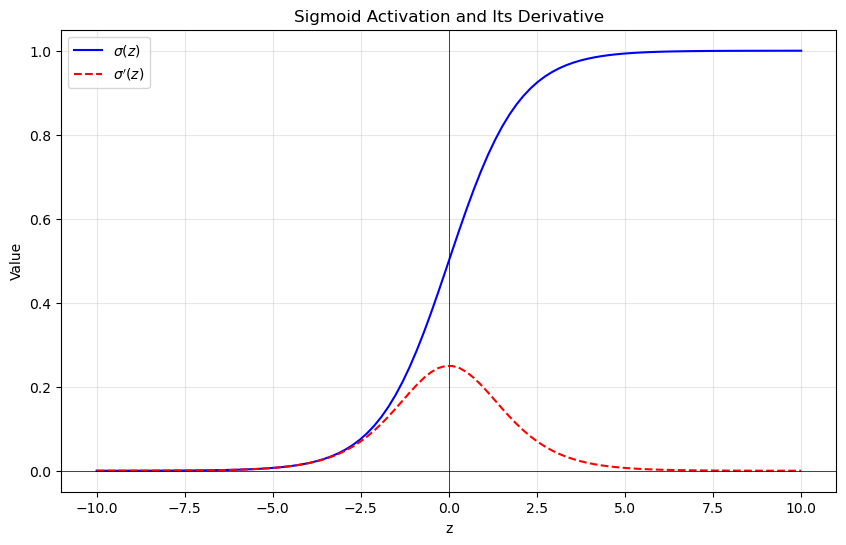

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid and derivative
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-10, 10, 100)
plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), 'b-', label=r'$\sigma(z)$')
plt.plot(z, sigmoid_prime(z), 'r--', label=r"$\sigma'(z)$")
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.title('Sigmoid Activation and Its Derivative')
plt.xlabel('z')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Full Backpropagation Code (One Step)

Let’s simulate one training step.

In [2]:
# Training example
x = 1500    # house size
y = 300000  # true price

# Initialize weights
w1, b1 = 0.1, 0.0
w2, b2 = 0.2, 0.0
eta = 0.0000001  # learning rate

# Forward pass
z1 = w1 * x + b1
a1 = sigmoid(z1)
y_hat = w2 * a1 + b2
L = (y_hat - y)**2

print(f"Initial Loss: {L:.2f}")

# Backward pass (Chain Rule!)
dL_dyhat = 2 * (y_hat - y)
dyhat_da1 = w2
da1_dz1 = a1 * (1 - a1)
dz1_dw1 = x

dL_dw1 = dL_dyhat * dyhat_da1 * da1_dz1 * dz1_dw1

# Update
w1 -= eta * dL_dw1

print(f"Gradient w.r.t. w1: {dL_dw1:.2f}")
print(f"New w1: {w1:.6f}")

Initial Loss: 89999880000.04
Gradient w.r.t. w1: -0.00
New w1: 0.100000


## Conclusion: Backpropagation = Chain Rule

> **Every AI model — from logistic regression to GPT — uses the Chain Rule recursively to compute gradients.**

You now **understand the math engine of AI**.

